In [1]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import sys 
import analysis_utils
sys.path.append("../")

from checkpoint import CheckPoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
perm_20 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm20_nep20.pt")
perm_40 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm40_nep20.pt")
perm_60 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm60_nep20.pt")
perm_80 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm80_nep20.pt")
perm_100 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm100_nep20.pt")
perm_140 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm140_nep20.pt")
perm_200 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm200_nep20.pt")
perm_400 = CheckPoint.from_pt(path="../models/num_permuted_alphabets/MLC_batchalph_dallstudy1_copy_perm400_nep20.pt")

all_training_runs = [perm_20, perm_40, perm_60, perm_80, perm_100, perm_140, perm_200, perm_400]

In [3]:
# check that training alphabets have no overlap with new alphabets:
df20 = pd.read_csv("../data/all_transformations_study1_copy_perm20/test.csv")
df40 = pd.read_csv("../data/all_transformations_study1_copy_perm40/test.csv")
df60 = pd.read_csv("../data/all_transformations_study1_copy_perm60/test.csv")
df80 = pd.read_csv("../data/all_transformations_study1_copy_perm80/test.csv")
df100 = pd.read_csv("../data/all_transformations_study1_copy_perm100/test.csv")
df140 = pd.read_csv("../data/all_transformations_study1_copy_perm140/test.csv")
df200 = pd.read_csv("../data/all_transformations_study1_copy_perm200/test.csv")
df400 = pd.read_csv("../data/all_transformations_study1_copy_perm400/test.csv")

all_training_alphabets = set(
    list(df20.alphabet.unique()) + 
    list(df40.alphabet.unique()) + 
    list(df60.alphabet.unique()) + 
    list(df80.alphabet.unique()) +
    list(df100.alphabet.unique()) +
    list(df140.alphabet.unique()) +
    list(df200.alphabet.unique()) +
    list(df400.alphabet.unique())
    )

df_new_alphs = pd.read_csv("../data/all_transformations_study1_new_alphabets/test.csv")
# only overlapping alphabet should be the standard alphabet:
all_training_alphabets & set(df_new_alphs.alphabet.unique())

{'a b c d e f g h i j k l m n o p q r s t u v w x y z'}

In [12]:
# predictions on new set of permuted alphabets
accs_new_alphabets = pd.DataFrame(columns=["batching_method", "accuracy in-dist", "accuracy out-of-dist"])
for i, cp in enumerate(all_training_runs):
    test_new_alph = cp.load_dataloaders(
        "../data/all_transformations_study1_new_alphabets", 
        use_datasets=["test"],
        verbose=False)[0]
    model = cp.load_model(verbose=False)
    pred = analysis_utils.predict_dataset(test_new_alph, model, alternative_rule_errors=False)
    # exclude standard alphabet:
    pred = pred[pred["n_perm"]!= 0]
    test_acc_in = np.mean(pred[pred.distribution == "in"]["correct"])
    test_acc_out_of = np.mean(pred[pred.distribution == "out-of"]["correct"])
    accs_new_alphabets.loc[i,:] = [cp.train_config.batching_method, test_acc_in, test_acc_out_of]
accs_new_alphabets.round(3)

Predicting: 370it [08:24,  1.36s/it]                         
Predicting: 370it [09:53,  1.61s/it]                         
Predicting: 370it [08:56,  1.45s/it]                         
Predicting: 370it [06:00,  1.02it/s]                         
Predicting: 370it [04:00,  1.54it/s]                         
Predicting: 370it [03:54,  1.58it/s]                         
Predicting: 370it [04:12,  1.46it/s]                         
Predicting: 370it [04:14,  1.45it/s]                         


,batching_method,accuracy in-dist,accuracy out-of-dist
0,alphabet,0.3045,0.034993
1,alphabet,0.526952,0.062103
2,alphabet,0.567022,0.053259
3,alphabet,0.704087,0.071332
4,alphabet,0.729846,0.068448
5,alphabet,0.98076,0.185541
6,alphabet,0.998728,0.262257
7,alphabet,0.815869,0.040185


In [13]:
accs_new_alphabets["perm. alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
accs_new_alphabets["new_alphabets"] = True
accs_new_alphabets.drop(columns=["batching_method"], inplace=True)

In [15]:
# add validation set accuracies for the last episode (i.e., on the trained alphabets)
data = [{**vars(train_run.train_config), **vars(train_run.mlc_config)} for train_run in all_training_runs]
for i, train_run in enumerate(all_training_runs):
    data[i]["loss"] = round(train_run.best_val_loss, 3)
    data[i]["accuracy in-dist"] = round(np.max([x["in"] for x in train_run.val_acc_hist]), 3)
    data[i]["accuracy out-of-dist"] = round(np.max([x["out-of"] for x in train_run.val_acc_hist]), 3)
df = pd.DataFrame(data)
df["perm. alphabets in training"] = [20, 40, 60, 80, 100, 140, 200, 400]
df["new_alphabets"] = False

In [16]:
# Merge the two DataFrames on the 'perm. alphabets in training' column
df = df[["accuracy in-dist","accuracy out-of-dist","perm. alphabets in training", "new_alphabets"]]

In [17]:
all_accs = pd.concat([df, accs_new_alphabets])

In [18]:
all_accs

,accuracy in-dist,accuracy out-of-dist,perm. alphabets in training,new_alphabets
0,0.9,0.1,20,False
1,0.949,0.126,40,False
2,0.936,0.093,60,False
3,0.947,0.138,80,False
4,0.931,0.104,100,False
5,1.0,0.238,140,False
6,1.0,0.271,200,False
7,0.809,0.05,400,False
0,0.3045,0.034993,20,True
1,0.526952,0.062103,40,True


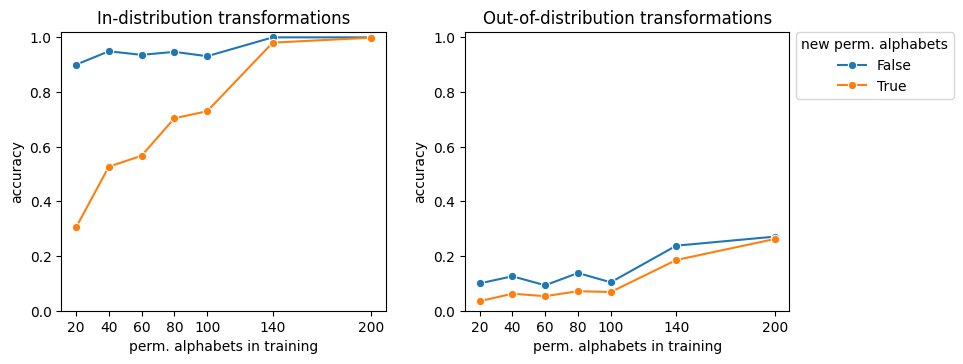

In [30]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
not_400 = all_accs[all_accs["perm. alphabets in training"]!=400]
_ = sns.lineplot(not_400, 
                 x="perm. alphabets in training", y="accuracy in-dist", 
                 hue="new_alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("In-distribution transformations")
_ = sns.lineplot(not_400, 
                    x="perm. alphabets in training", y="accuracy out-of-dist", 
                    hue="new_alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].legend(title="new perm. alphabets", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
_ = ax[1].set_title("Out-of-distribution transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)

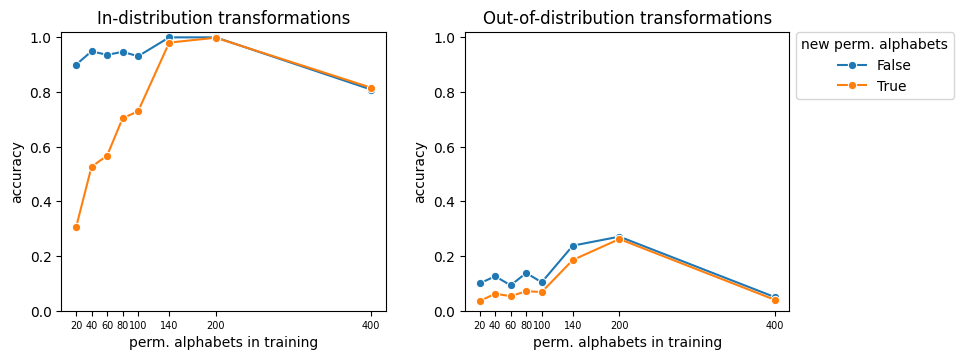

In [41]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(10,4))
_ = sns.lineplot(all_accs, 
                 x="perm. alphabets in training", y="accuracy in-dist", 
                 hue="new_alphabets", 
                 ax=ax[0], 
                 markers=True, 
                 marker="o")
_ = ax[0].set_ylim((0,1.02))
_ = ax[0].set_xticks([20, 40, 60, 80, 100, 140, 200, 400])
_ = ax[0].set_ylabel("accuracy")
_ = ax[0].legend().remove()
_ = ax[0].set_title("In-distribution transformations")
_ = sns.lineplot(all_accs, 
                    x="perm. alphabets in training", y="accuracy out-of-dist", 
                    hue="new_alphabets", 
                    markers=True, 
                    marker="o",
                    ax=ax[1])
_ = ax[1].set_ylabel("accuracy")
_ = ax[1].set_ylim((0,1.02))
_ = ax[1].legend(title="new perm. alphabets", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
_ = ax[1].set_title("Out-of-distribution transformations")

_ = fig.tight_layout(pad=2)
_ = fig.subplots_adjust(hspace=0.3)
ax[0].tick_params(axis='x', labelsize=7)
ax[1].tick_params(axis='x', labelsize=7)

### Trained Model with 200 Permuted Alphabets

In [37]:
pd.DataFrame(perm_200.val_acc_hist)[["epoch","copy","noncopy"]]

,epoch,copy,noncopy
0,1,0.782395,0.134863
1,2,0.867312,0.287969
2,3,0.860660,0.316981
3,4,0.882645,0.326784
4,5,0.885928,0.359093
5,6,0.893962,0.397248
6,7,0.853274,0.420810
7,8,0.861826,0.432810
8,9,0.860271,0.454657
9,10,0.790213,0.577168


Loaded following dataloaders:
val dataloader (n=45,901)
Training information:
Best Validation Loss: 0.604
Best Validation Accuracy: 0.717


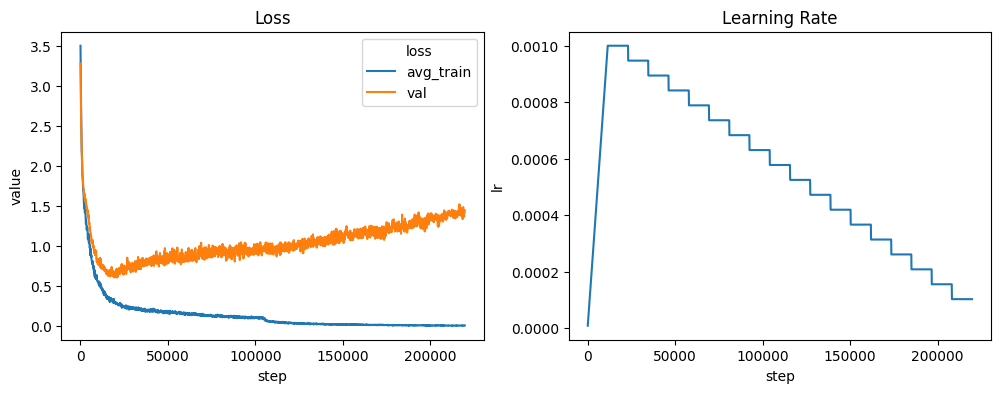

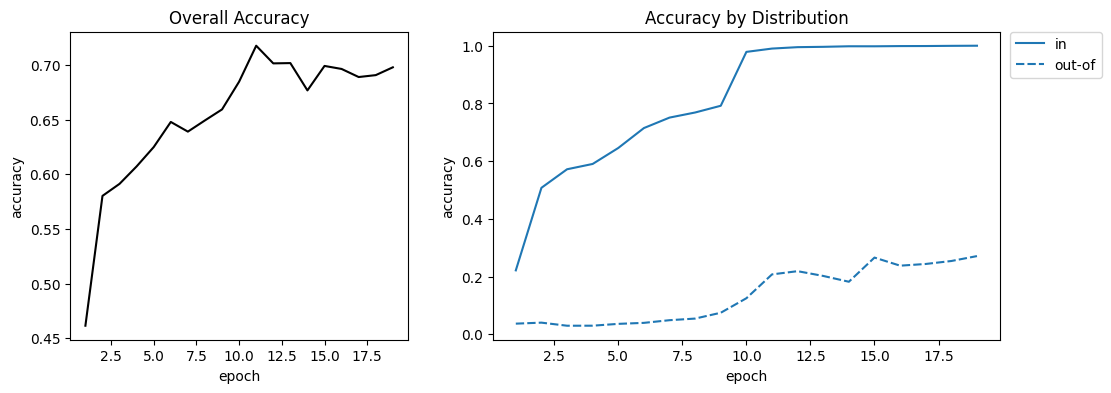

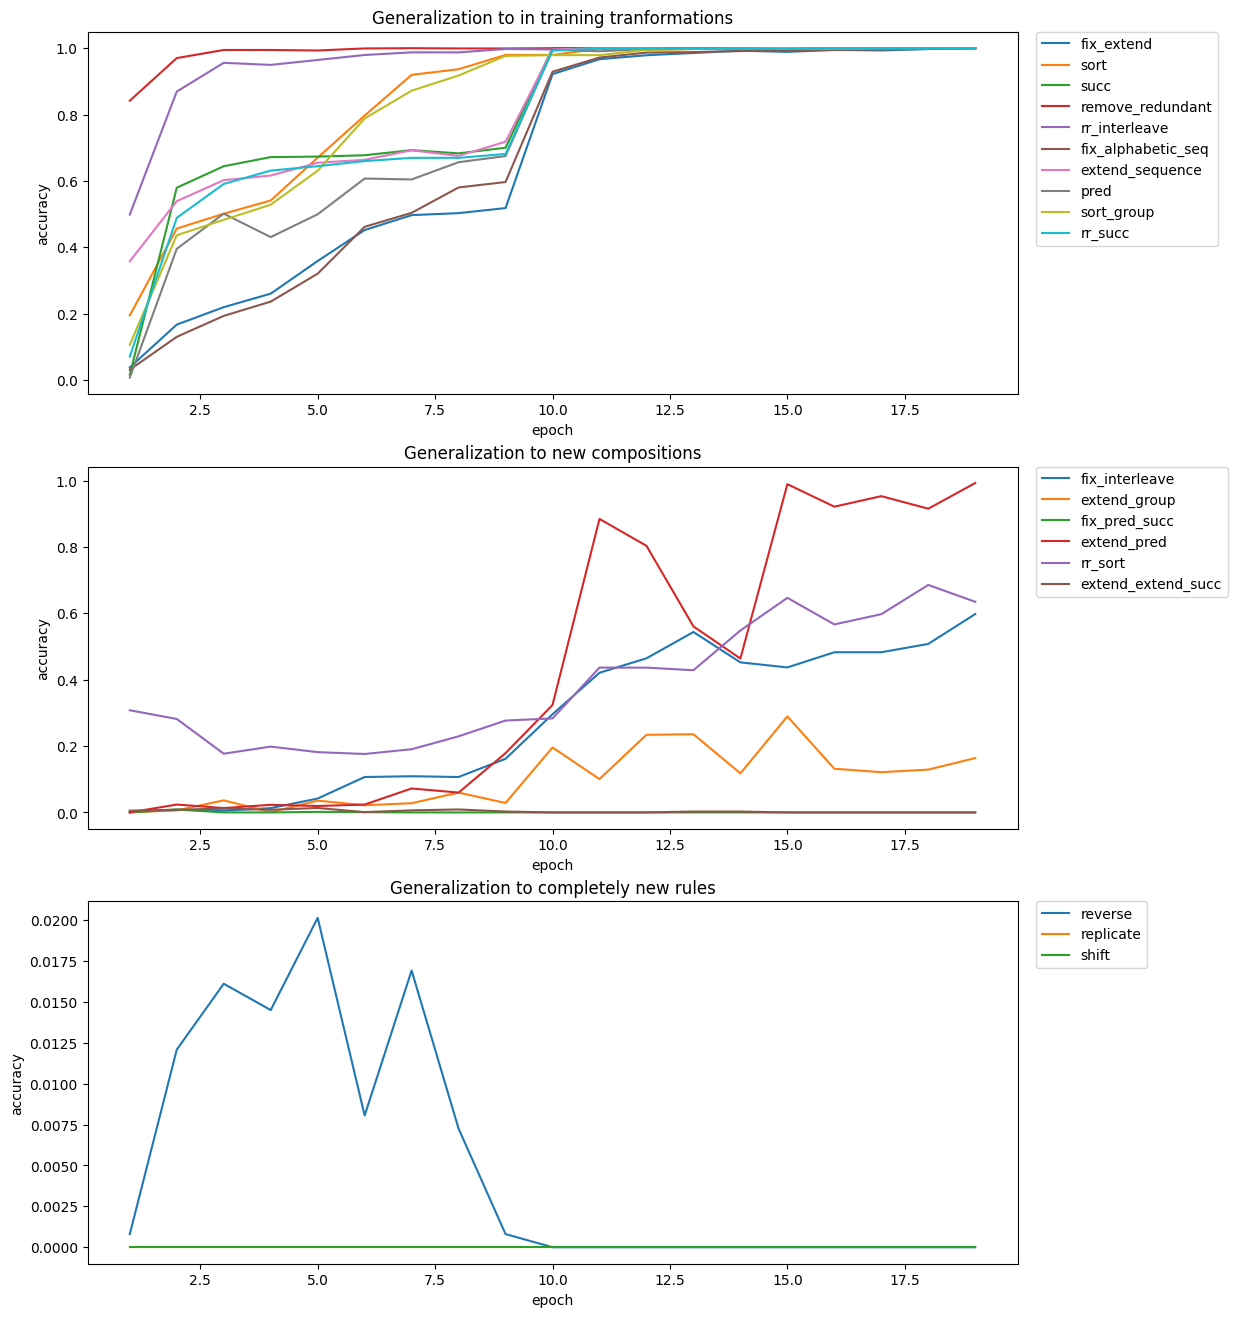

In [32]:
val = perm_200.load_dataloaders(f"../{perm_200.train_config.dir_data}", use_datasets=["val"])[0]
_ = analysis_utils.training_history(perm_200, val)